# Conditional Generative Model for Radio Galaxy Projections

Learns to generate synthetic 89×89 radio galaxy images conditioned on morphology labels.

**Pipeline:**
```
class label y  →  NSF sample z ∈ ℝ^d  →  FlowMatchingUNet  →  89×89 image
```

**Two components trained sequentially:**

| Component | Input | Output | Loss |
|-----------|-------|--------|------|
| **FlowMatchingUNet** | BYOL projection z | 89×89 image | flow-matching MSE |
| **Conditional NSF** (`zuko.NSF`) | class label y | projection z ~ p(z\|y) | negative log-likelihood |

At generation time: sample z from the NSF conditioned on a class label, decode with the U-Net.

## 1. Imports

In [1]:
import sys
import copy
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import zuko
import umap
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

/users/mbredber/.venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

Edit the values below before running the rest of the notebook.

| Key | Description |
|-----|-------------|
| `base_dir` | BYOL run output directory — must contain `byol_model_best.pt` and saved projections |
| `images_path` | Path to the raw LoTSS image array `(N, 89, 89)` |
| `label_subset` | Which LoTSS label group to condition on (see table below) |
| `use_projections` | `True` → use PCA/MLP projection (256-dim); `False` → raw encoder features |
| `decoder_type` | `"flow"` → flow-matching U-Net (sharp); `"cnn"` → fast FC decoder (blurry) |

**Label subsets:**

| `label_subset` | Columns | Classes |
|----------------|---------|---------|
| `"classical"` | 0–1 | FRI, FRII |
| `"classical_pure"` | 0–1 | FRI, FRII (unambiguous only) |
| `"initial"` | 0–4 | FRI, FRII, Hybrids, Spirals, Relaxed doubles |
| `"initial_pure"` | 0–4 | same, single-label sources only |
| `"morphology"` | 5–14 | C-curv … Restarted |
| `"environment"` | 16–19 | Cluster, Merger, Diffuse, Unknown |

In [2]:
CONFIG = {
    # Point to the run output directory (data/ subdir is auto-detected; embeddings/ also supported)
    "base_dir":        ROOT / "outputs/run_cnxt_pca_pond_step_wd_20260507_1151",
    # generative_dir: path to a pre-trained generative run (decoder.pt + nsf.pt).
    #   Set to None to train from scratch instead.
    "generative_dir":  ROOT / "outputs/run_cnxt_pca_pond_step_wd_20260507_1151/generative/flow_initial_20260507_1437",
    "images_path":     ROOT / "data/preprocessed/lotss/images_filtered.npy",
    "labels_path":     ROOT / "data/preprocessed/lotss/labels_filtered.npy",
    # label_subset: 'classical' | 'classical_pure' | 'initial' | 'initial_pure' |
    #               'environment' | 'derived' | 'morphology' | 'all' | 'pure'
    # or a custom list of int indices into ALL_CLASS_NAMES
    "label_subset":    "initial",
    # ── Decoder ───────────────────────────────────────────────────────────────
    # use_projections: True  → decoder and NSF both operate on the PCA/MLP projection
    #                          (lower-dim, semantically rich, consistent with BYOL training)
    #                  False → decoder uses raw encoder features (higher-dim)
    "use_projections": True,
    # decoder_type: "flow" → flow-matching U-Net (sharp outputs, ~20 inference steps)
    #               "cnn"  → simple FC decoder (fast, blurrier)
    "decoder_type":    "flow",
    "flow_n_steps":    20,          # Euler integration steps at generation time
    # ── Training ──────────────────────────────────────────────────────────────
    "flow_epochs":     200,
    "decoder_epochs":  300,
    "decoder_lr":      1e-4,
    "decoder_patience": 40,
    "decoder_loss_alpha": 0.7,      # MSE weight for "cnn" decoder; (1-α) → L1
    "batch_size":      256,
    "lr":              3e-4,
    "n_flow_transforms": 8,
    "seed":            42,
    # ── Regularisation ────────────────────────────────────────────────────────
    "decoder_dropout":      0.3,    # CNN decoder only; set 0.0 to disable
    "decoder_weight_decay": 1e-4,
    "flow_weight_decay":    1e-5,
    "flow_feat_noise":      0.05,
}

# | label_subset      | Columns   | Classes                                                          |
# |-------------------|-----------|------------------------------------------------------------------|
# | "classical"       | 0–1       | FRI, FRII                                                        |
# | "classical_pure"  | 0–1       | FRI, FRII — sources with exactly one initial label               |
# | "initial"         | 0–4       | FRI, FRII, Hybrids, Spirals, Relaxed doubles                     |
# | "initial_pure"    | 0–4       | FRI, FRII, Hybrids, Spirals, Relaxed doubles — one initial label |
# | "environment"     | 16–19     | Cluster, Merger, Diffuse, Unknown                                |
# | "derived"         | computed  | Pure hybrid, FR hybrid, Curved FRI, Curved FRII, Straight+mHS   |
# | "morphology"      | 5–14      | C-curv … Restarted                                               |
# | "all"             | 0–19      | All 20 classes                                                   |
# | "pure"            | 0–19      | All 20 classes (single-label across all 20 only)                 |
#
# Derived label definitions (computed, not raw columns):
#   1. Pure hybrid    : col2 & ~col0 & ~col1
#   2. FR hybrid      : col2 & (col0 | col1)
#   3. Curved FRI     : col0 & (col5 | col6)
#   4. Curved FRII    : col1 & (col5 | col6)
#   5. Straight+mHS   : col10 & col11
LABEL_SUBSETS = {
    "classical":      [0, 1],
    "classical_pure": [0, 1],
    "initial":        list(range(0, 5)),
    "initial_pure":   list(range(0, 5)),
    "environment":    list(range(16, 20)),
    "derived":        None,  # computed from label combinations
    "morphology":     list(range(5, 15)),
    "all":            list(range(0, 20)),
    "pure":           list(range(0, 20)),
}

DERIVED_CLASS_NAMES = [
    'Pure hybrid',       # col2 & ~col0 & ~col1
    'FR hybrid',         # col2 & (col0 | col1)
    'Curved FRI',        # col0 & (col5 | col6)
    'Curved FRII',       # col1 & (col5 | col6)
    'Straight+multi-HS', # col10 & col11
]

ALL_CLASS_NAMES = [
    "FRI", "FRII", "Hybrids", "Spirals", "Relaxed doubles",        # 0-4  initial
    "C-curv", "S-curv", "Misalign", "Wings", "X-shaped",           # 5-9  morphology
    "Straight jets", "Multi hotspots", "Cont. jets", "Banding",    # 10-13
    "One-sided", "Restarted",                                       # 14-15
    "Cluster", "Merger", "Diffuse", "Unknown",                      # 16-19 environment
]

print("Config loaded.")
print(f"  Decoder:          {CONFIG['decoder_type']} | use_projections: {CONFIG['use_projections']}")
print(f"  Label subset:     {CONFIG['label_subset']}")
print(f"  Base dir:         {CONFIG['base_dir']}")

Config loaded.
  Decoder:          flow | use_projections: True
  Label subset:     initial
  Base dir:         /users/mbredber/p3_SUPLAT/outputs/run_cnxt_pca_pond_step_wd_20260507_1151


## 3. Load Pre-Saved Projections

Loads `train/val/test_projections.npy` and `train/val/test_labels.npy` from the
BYOL run directory.  These pre-extracted projections are used directly for NSF
training — no images or GPU needed at this stage.

The selected `label_subset` is applied here to slice the 20-dim multi-hot label
array down to only the classes of interest.

In [3]:
_base   = Path(CONFIG["base_dir"])
proj_dir = (_base / "data"       if (_base / "data").is_dir()
            else _base / "embeddings" if (_base / "embeddings").is_dir()
            else _base)

train_z = np.load(proj_dir / "train_projections.npy").astype(np.float32)
val_z   = np.load(proj_dir / "val_projections.npy").astype(np.float32)
test_z  = np.load(proj_dir / "test_projections.npy").astype(np.float32)

train_lbl_full = np.load(proj_dir / "train_labels.npy").astype(np.float32)
val_lbl_full   = np.load(proj_dir / "val_labels.npy").astype(np.float32)
test_lbl_full  = np.load(proj_dir / "test_labels.npy").astype(np.float32)

# Select label subset
label_subset = CONFIG["label_subset"]
if isinstance(label_subset, list):
    label_idx = label_subset
else:
    label_idx = LABEL_SUBSETS[label_subset]

# For "derived": compute 5 boolean combination columns
def _make_derived(y):
    c = lambda i: y[:, i].astype(bool)
    return np.stack([
        ( c(2) & ~c(0) & ~c(1)).astype(np.float32),   # Pure hybrid
        ( c(2) &  (c(0) | c(1))).astype(np.float32),  # FR hybrid
        ( c(0) &  (c(5) | c(6))).astype(np.float32),  # Curved FRI
        ( c(1) &  (c(5) | c(6))).astype(np.float32),  # Curved FRII
        (c(10) &   c(11)).astype(np.float32),          # Straight + multi-HS
    ], axis=1)

if label_subset == "derived":
    train_y = _make_derived(train_lbl_full)
    val_y   = _make_derived(val_lbl_full)
    test_y  = _make_derived(test_lbl_full)
    label_names_subset = DERIVED_CLASS_NAMES
else:
    train_y = train_lbl_full[:, label_idx]
    val_y   = val_lbl_full[:, label_idx]
    test_y  = test_lbl_full[:, label_idx]
    label_names_subset = [ALL_CLASS_NAMES[i] for i in label_idx]

n_labels = len(label_names_subset)

# Pure filtering — always define masks (all-True by default)
keep_train_mask = np.ones(len(train_lbl_full), dtype=bool)
keep_val_mask   = np.ones(len(val_lbl_full),   dtype=bool)
keep_test_mask  = np.ones(len(test_lbl_full),  dtype=bool)

if label_subset == "pure":
    keep_train_mask = train_lbl_full.sum(axis=1) == 1
    keep_val_mask   = val_lbl_full.sum(axis=1)   == 1
    keep_test_mask  = test_lbl_full.sum(axis=1)  == 1
    print(f"Pure filter (all 20)   : {keep_train_mask.sum()} train / {keep_val_mask.sum()} val / {keep_test_mask.sum()} test retained")
elif label_subset in ("classical_pure", "initial_pure"):
    keep_train_mask = train_lbl_full[:, 0:5].sum(axis=1) == 1
    keep_val_mask   = val_lbl_full[:, 0:5].sum(axis=1)   == 1
    keep_test_mask  = test_lbl_full[:, 0:5].sum(axis=1)  == 1
    print(f"Initial-pure filter    : {keep_train_mask.sum()} train / {keep_val_mask.sum()} val / {keep_test_mask.sum()} test retained")

train_z, train_y = train_z[keep_train_mask], train_y[keep_train_mask]
val_z,   val_y   = val_z[keep_val_mask],     val_y[keep_val_mask]
test_z,  test_y  = test_z[keep_test_mask],   test_y[keep_test_mask]

print(f"Projections dir: {proj_dir}")
print(f"Label subset ({n_labels}): {label_names_subset}")
print(f"Train z: {train_z.shape} | Val z: {val_z.shape} | Test z: {test_z.shape}")
print(f"Train labels: {train_y.shape}")
print(f"Label prevalence (train):\n",
      dict(zip(label_names_subset, train_y.mean(axis=0).round(3))))

Projections dir: /users/mbredber/p3_SUPLAT/outputs/run_cnxt_pca_pond_step_wd_20260507_1151/data
Label subset (5): ['FRI', 'FRII', 'Hybrids', 'Spirals', 'Relaxed doubles']
Train z: (5317, 192) | Val z: (1139, 192) | Test z: (1140, 192)
Train labels: (5317, 5)
Label prevalence (train):
 {'FRI': np.float32(0.317), 'FRII': np.float32(0.621), 'Hybrids': np.float32(0.096), 'Spirals': np.float32(0.018), 'Relaxed doubles': np.float32(0.047)}


## 4. Align Projections with Images

The decoder needs `(projection z, image)` pairs.  Two strategies are tried in order:

1. **Index files** — load `train_idx.npy` / `val_idx.npy` saved alongside the
   projections, then index the raw image array directly.  Fast, no GPU needed.
2. **Re-extraction fallback** — if index files are missing (older BYOL runs),
   load the BYOL checkpoint and re-extract projections from images via frozen
   forward pass.

Which path is taken is printed at runtime.

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

USE_PROJECTIONS = CONFIG.get("use_projections", True)
DECODER_TYPE    = CONFIG.get("decoder_type", "flow")

print("Loading images…")
all_images = np.load(CONFIG["images_path"])   # (N, 89, 89) uint8
print(f"  Images: {all_images.shape}, dtype={all_images.dtype}")

base_dir = Path(CONFIG["base_dir"])
proj_dir = (base_dir / "data"       if (base_dir / "data").is_dir()
            else base_dir / "embeddings" if (base_dir / "embeddings").is_dir()
            else base_dir)
data_dir = base_dir / "data"
ckpt_path = Path(CONFIG["byol_checkpoint"]) if "byol_checkpoint" in CONFIG \
            else base_dir / "byol_model_best.pt"
print(f"Projections dir: {proj_dir}")

# idx files are in data/ (current runs) or embeddings/ (old runs)
def _find_idx_dir(*dirs):
    for d in dirs:
        if all((d / f).exists() for f in ("train_idx.npy", "val_idx.npy", "test_idx.npy")):
            return d
    return None

idx_dir = _find_idx_dir(proj_dir)

def _strip_compile_prefix(sd):
    p = "_orig_mod."
    return {k[len(p):] if k.startswith(p) else k: v for k, v in sd.items()} \
           if any(k.startswith(p) for k in sd) else sd

def infer_model_type(sd):
    keys = set(sd.keys())
    if any("online_encoder.features.1.0.block.0.0.weight" in k for k in keys): return "efficientnet-b0"
    if any("online_encoder.features.1.0.block.0.weight"   in k for k in keys): return "convnext-tiny"
    if any("online_encoder.layer1.0.conv1.weight"         in k for k in keys):
        proj = sd.get("online_projector.net.0.weight")
        return "resnet50" if (proj is not None and proj.shape[1] == 2048) else "resnet18"
    if any("online_encoder.conv1.weight" in k for k in keys): return "convnet"
    return None

def infer_projection_config(sd):
    mode = "pca" if "online_projector.mean_" in sd else "mlp"
    pred_w = sd.get("online_predictor.net.0.weight")
    return mode, int(pred_w.shape[1]) if pred_w is not None else 256

def prepare_pca_model(model, sd):
    from suplat.models.byol_models import PCAProjection, PredictionHead
    for prefix in ("online_projector", "target_projector"):
        proj = getattr(model, prefix, None)
        if not isinstance(proj, PCAProjection): continue
        for buf in ("mean_", "components_", "active_mask_"):
            key = f"{prefix}.{buf}"
            if key in sd: proj.register_buffer(buf, sd[key].clone())
        proj._fitted = True
    if model.online_predictor is None and "online_predictor.net.0.weight" in sd:
        proj_dim = sd["online_predictor.net.0.weight"].shape[1]
        hidden_dim, bn_momentum = model._predictor_config
        model.online_predictor = PredictionHead(
            in_dim=proj_dim, hidden_dim=hidden_dim, out_dim=proj_dim, bn_momentum=bn_momentum)

def patch_missing_active_mask(model, sd):
    from suplat.models.byol_models import PCAProjection
    for prefix in ("online_projector", "target_projector"):
        proj = getattr(model, prefix, None)
        if isinstance(proj, PCAProjection) and not hasattr(proj, "active_mask_"):
            n = proj.mean_.shape[0]
            proj.register_buffer("active_mask_", torch.ones(n, dtype=torch.bool))
            print(f"  [PCA] {prefix}: patched active_mask_ ({n} features)")

def load_byol_from_checkpoint(path, device):
    from suplat.models.byol_models import (
        BYOLEfficient, BYOLEfficientNetB0, BYOLPretrainedBackbone,
        create_resnet18_backbone, create_resnet50_backbone, create_convnext_tiny_backbone,
    )
    ckpt = torch.load(path, map_location=device)
    sd   = _strip_compile_prefix(ckpt["model_state_dict"])
    model_type          = infer_model_type(sd)
    proj_mode, proj_dim = infer_projection_config(sd)
    print(f"  model_type: {model_type!r} | projection: {proj_mode!r} dim={proj_dim}")
    if   model_type == "convnet":       model = BYOLEfficient(feature_compression_mode=proj_mode, projection_dim=proj_dim)
    elif model_type == "efficientnet-b0": model = BYOLEfficientNetB0(feature_compression_mode=proj_mode, projection_dim=proj_dim)
    elif model_type == "resnet18":
        bb, enc = create_resnet18_backbone(num_channels=1)
        model = BYOLPretrainedBackbone(bb, encoder_dim=enc, projection_dim=proj_dim, feature_compression_mode=proj_mode)
    elif model_type == "resnet50":
        bb, enc = create_resnet50_backbone(num_channels=1)
        model = BYOLPretrainedBackbone(bb, encoder_dim=enc, projection_dim=proj_dim, feature_compression_mode=proj_mode)
    elif model_type == "convnext-tiny":
        bb, enc = create_convnext_tiny_backbone(num_channels=1)
        model = BYOLPretrainedBackbone(bb, encoder_dim=enc, projection_dim=proj_dim, feature_compression_mode=proj_mode)
    else: raise ValueError(f"Could not detect model type from checkpoint")
    if proj_mode == "pca": prepare_pca_model(model, sd)
    model.load_state_dict(sd)
    if proj_mode == "pca": patch_missing_active_mask(model, sd)
    model.eval().to(device)
    for p in model.parameters(): p.requires_grad = False
    print(f"  BYOL loaded (epoch {ckpt['epoch']}, best_val_loss={ckpt.get('best_val_loss','?'):.4f})")
    return model

# BYOL is always loaded — needed for Cell 8 Mode A (encode real images)
print("Loading BYOL checkpoint…")
byol = load_byol_from_checkpoint(ckpt_path, device)

# ── Load or replicate split indices ───────────────────────────────────────────
if idx_dir is not None:
    print(f"Loading saved split indices from {idx_dir.name}/")
    train_idx = np.load(idx_dir / "train_idx.npy")
    val_idx   = np.load(idx_dir / "val_idx.npy")
    test_idx  = np.load(idx_dir / "test_idx.npy")
    train_proj = torch.from_numpy(np.load(proj_dir / "train_projections.npy").astype(np.float32))
    val_proj   = torch.from_numpy(np.load(proj_dir / "val_projections.npy").astype(np.float32))
    test_proj  = torch.from_numpy(np.load(proj_dir / "test_projections.npy").astype(np.float32))
else:
    print("Index files not found — replicating split")
    all_idx = np.arange(len(all_images))
    train_idx, temp_idx = train_test_split(all_idx, test_size=0.30, random_state=CONFIG["seed"])
    val_idx,   test_idx = train_test_split(temp_idx, test_size=0.50, random_state=CONFIG["seed"])
    def _extract_proj(img_array, bs=128):
        imgs_t = torch.from_numpy(img_array.astype(np.float32) / 255.0).unsqueeze(1)
        out = []
        with torch.no_grad():
            for (x,) in DataLoader(TensorDataset(imgs_t), batch_size=bs):
                out.append(byol.online_projector(byol.online_encoder(x.to(device))).cpu())
        return torch.cat(out)
    print("  Extracting projections…")
    train_proj = _extract_proj(all_images[train_idx])
    val_proj   = _extract_proj(all_images[val_idx])
    test_proj  = _extract_proj(all_images[test_idx])

# ── Image tensors (always needed for decoder training) ────────────────────────
# n_*: saved projections may be shorter than full split (drop_last=True with --compile)
# keep_*_mask from Cell 2 is sized to match the saved projections, so clip to that.
n_train, n_val, n_test = len(keep_train_mask), len(keep_val_mask), len(keep_test_mask)
train_imgs = torch.from_numpy(all_images[train_idx[:n_train]].astype(np.float32) / 255.0).unsqueeze(1)
val_imgs   = torch.from_numpy(all_images[val_idx[:n_val]  ].astype(np.float32)   / 255.0).unsqueeze(1)
test_imgs  = torch.from_numpy(all_images[test_idx[:n_test] ].astype(np.float32)  / 255.0).unsqueeze(1)

# ── Encoder features — only needed when use_projections=False ─────────────────
if not USE_PROJECTIONS:
    def _extract_feats(img_array, bs=128):
        imgs_t = torch.from_numpy(img_array.astype(np.float32) / 255.0).unsqueeze(1)
        out = []
        with torch.no_grad():
            for (x,) in DataLoader(TensorDataset(imgs_t), batch_size=bs):
                out.append(byol.online_encoder(x.to(device)).cpu())
        return torch.cat(out)
    print("Extracting raw encoder features for decoder…")
    _train_feats_raw = _extract_feats(all_images[train_idx])[:n_train]
    _val_feats_raw   = _extract_feats(all_images[val_idx])[:n_val]
    _test_feats_raw  = _extract_feats(all_images[test_idx])[:n_test]

# ── Apply label/pure filter mask from Cell 2 ──────────────────────────────────
train_imgs = train_imgs[keep_train_mask]
val_imgs   = val_imgs[keep_val_mask]
test_imgs  = test_imgs[keep_test_mask]
train_proj  = train_proj[keep_train_mask]
val_proj    = val_proj[keep_val_mask]
test_proj   = test_proj[keep_test_mask]

# ── Decoder conditioning: projections (default) or raw encoder features ────────
if USE_PROJECTIONS:
    train_feats = train_proj   # same tensor, projections are the decoder input
    val_feats   = val_proj
    test_feats  = test_proj
    print("Decoder input: PCA/MLP projections")
else:
    train_feats = _train_feats_raw[keep_train_mask]
    val_feats   = _val_feats_raw[keep_val_mask]
    test_feats  = _test_feats_raw[keep_test_mask]
    print("Decoder input: raw encoder features")

print(f"\nSplit sizes (after filter) — train: {train_feats.shape[0]} | val: {val_feats.shape[0]} | test: {test_feats.shape[0]}")
print(f"Decoder input dim: {train_feats.shape[1]}  |  NSF input dim: {train_proj.shape[1]}")

Device: cuda
Loading images…
  Images: (7596, 89, 89), dtype=uint8
Projections dir: /users/mbredber/p3_SUPLAT/outputs/run_cnxt_pca_pond_step_wd_20260507_1151/data
Loading BYOL checkpoint…
  model_type: 'convnext-tiny' | projection: 'pca' dim=192
  BYOL loaded (epoch 400, best_val_loss=0.0549)
Loading saved split indices from data/
Decoder input: PCA/MLP projections

Split sizes (after filter) — train: 5317 | val: 1139 | test: 1140
Decoder input dim: 192  |  NSF input dim: 192


## 5. Decoder — Flow Matching U-Net

The decoder is a **`FlowMatchingUNet`** that generates 89×89 images conditioned on a
BYOL projection `z`.

### Training: straight-line flow matching

A linear interpolation defines a probability path between Gaussian noise and the real image:

```
x_t = (1 − t) · x_noise  +  t · x_real       t ~ U[0, 1],  x_noise ~ N(0, 1)
```

The constant velocity along this path is `v* = x_real − x_noise`.  The U-Net is trained
to predict this velocity at any point along the path:

```
Loss = E_{t, x_real, x_noise} [ ‖ v_θ(x_t, t, z) − (x_real − x_noise) ‖² ]
```

Because the path is straight, a single Euler step is theoretically exact — in practice
20 steps are used to allow the network to correct errors.

### Architecture

```
x_t (1×89×89) ──┐
z   (d)    ──→  cond ──→ scale/shift at every residual block
t   (scalar) ──┘

Encoder:    Conv → ResBlock(C)   → stride-2 → ResBlock(2C) → stride-2 → ResBlock(4C) → stride-2
Bottleneck: ResBlock(8C) × 2
Decoder:    upsample → ResBlock(8C) ⊕ skip → upsample → ResBlock(4C) ⊕ skip → ...
Output:     GroupNorm → SiLU → Conv → velocity (1×89×89, unbounded)
```

`z` and a sinusoidal time embedding of `t` are concatenated and injected into every
residual block via **AdaIN-style scale+shift**, so morphology conditioning is applied
at all spatial scales.

In [5]:
class _SinusoidalEmbedding(nn.Module):
    # Sinusoidal time embedding for flow timestep t in [0, 1].
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / max(half - 1, 1))
        x     = t[:, None] * freqs[None]
        return torch.cat([x.sin(), x.cos()], dim=-1)


class _CondResBlock(nn.Module):
    # Residual conv block: GroupNorm + AdaIN-style scale/shift from conditioning vector.
    def __init__(self, channels, cond_dim):
        super().__init__()
        g = min(8, channels)
        self.norm1 = nn.GroupNorm(g, channels)
        self.norm2 = nn.GroupNorm(g, channels)
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.cond  = nn.Linear(cond_dim, 2 * channels)

    def forward(self, x, cond):
        scale, shift = self.cond(cond).chunk(2, dim=-1)
        h = F.silu(self.norm1(x))
        h = self.conv1(h)
        h = F.silu(self.norm2(h) * (1 + scale[..., None, None]) + shift[..., None, None])
        return x + self.conv2(h)


class FlowMatchingUNet(nn.Module):
    # Flow-matching velocity network: v_θ(x_t, t, z) → velocity field (B, 1, 89, 89).
    # Training loss: MSE( v_θ(x_t, t, z), x_real − x_noise )
    # Inference:     Euler ODE  x_{k+1} = x_k + (1/K) · v_θ(x_k, k/K, z)  from x_0 ~ N(0,1).
    IMG_SIZE = 89

    def __init__(self, z_dim, t_dim=128, base_ch=32):
        super().__init__()
        C        = base_ch
        cond_dim = z_dim + t_dim

        self.t_embed = nn.Sequential(
            _SinusoidalEmbedding(t_dim),
            nn.Linear(t_dim, t_dim), nn.SiLU(),
            nn.Linear(t_dim, t_dim),
        )
        self.in_conv = nn.Conv2d(1, C, 3, padding=1)
        self.res_e1  = _CondResBlock(C,    cond_dim)
        self.down1   = nn.Conv2d(C,   C*2, 3, stride=2, padding=1)
        self.res_e2  = _CondResBlock(C*2,  cond_dim)
        self.down2   = nn.Conv2d(C*2, C*4, 3, stride=2, padding=1)
        self.res_e3  = _CondResBlock(C*4,  cond_dim)
        self.down3   = nn.Conv2d(C*4, C*8, 3, stride=2, padding=1)
        self.res_m1  = _CondResBlock(C*8, cond_dim)
        self.res_m2  = _CondResBlock(C*8, cond_dim)
        self.up3     = nn.Conv2d(C*8, C*4, 3, padding=1)
        self.res_d3  = _CondResBlock(C*8, cond_dim)
        self.up2     = nn.Conv2d(C*8, C*2, 3, padding=1)
        self.res_d2  = _CondResBlock(C*4, cond_dim)
        self.up1     = nn.Conv2d(C*4, C,   3, padding=1)
        self.res_d1  = _CondResBlock(C*2, cond_dim)
        self.out_norm = nn.GroupNorm(min(8, C*2), C*2)
        self.out_conv = nn.Conv2d(C*2, 1, 3, padding=1)

    def forward(self, x_t, t, z):
        cond = torch.cat([z, self.t_embed(t)], dim=-1)
        h    = F.silu(self.in_conv(x_t))
        h1   = self.res_e1(h, cond)
        h2   = self.res_e2(F.silu(self.down1(h1)), cond)
        h3   = self.res_e3(F.silu(self.down2(h2)), cond)
        h    = F.silu(self.down3(h3))
        h    = self.res_m1(h, cond)
        h    = self.res_m2(h, cond)
        h    = F.silu(self.up3(F.interpolate(h, size=h3.shape[-2:], mode='nearest')))
        h    = self.res_d3(torch.cat([h, h3], dim=1), cond)
        h    = F.silu(self.up2(F.interpolate(h, size=h2.shape[-2:], mode='nearest')))
        h    = self.res_d2(torch.cat([h, h2], dim=1), cond)
        h    = F.silu(self.up1(F.interpolate(h, size=h1.shape[-2:], mode='nearest')))
        h    = self.res_d1(torch.cat([h, h1], dim=1), cond)
        return self.out_conv(F.silu(self.out_norm(h)))

    @torch.no_grad()
    def sample(self, z, n_steps=20):
        # Euler ODE: integrate velocity field from N(0,1) to image.
        self.eval()
        x  = torch.randn(z.shape[0], 1, self.IMG_SIZE, self.IMG_SIZE, device=z.device)
        dt = 1.0 / n_steps
        for i in range(n_steps):
            t = torch.full((z.shape[0],), i * dt, device=z.device)
            x = x + self(x, t, z) * dt
        return torch.clamp(x, 0.0, 1.0)


# Sanity check
_zdim = 192
_flow = FlowMatchingUNet(z_dim=_zdim, base_ch=32)
_x, _t, _z = torch.randn(4, 1, 89, 89), torch.rand(4), torch.randn(4, _zdim)
print(f"FlowMatchingUNet  velocity: {_flow(_x, _t, _z).shape} | params: {sum(p.numel() for p in _flow.parameters()):,}")
print(f"FlowMatchingUNet  sample:   {_flow.sample(_z, n_steps=2).shape}")
del _flow, _x, _t, _z

ProjectionDecoder  output: torch.Size([4, 1, 89, 89]) | params: 7,159,905
FlowMatchingUNet velocity output: torch.Size([4, 1, 89, 89]) | params: 5,951,073
FlowMatchingUNet sample  output:  torch.Size([4, 1, 89, 89])


## 6. Load or Train Decoder

If `CONFIG["generative_dir"]` points to a pre-trained run, the decoder is loaded
from `decoder.pt` in that directory.  Otherwise it is trained from scratch.

**Loss** (straight-line flow matching):

```
x_t = (1 − t) · noise  +  t · x_real        t ~ U[0,1]
Loss = MSE( v_θ(x_t, t, z),  x_real − noise )
```

- **Optimiser**: Adam with cosine LR annealing
- **Early stopping**: patience = `CONFIG["decoder_patience"]`

In [6]:
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

FLOW_N_STEPS = CONFIG.get("flow_n_steps", 20)
FEAT_DIM     = train_feats.shape[1]

_gen_dir = Path(CONFIG["generative_dir"]) if CONFIG.get("generative_dir") else None

if _gen_dir is not None:
    # ── Load pre-trained decoder ───────────────────────────────────────────────
    _ckpt    = torch.load(_gen_dir / "decoder.pt", map_location=device, weights_only=False)
    FEAT_DIM = _ckpt["feat_dim"]
    decoder  = FlowMatchingUNet(z_dim=FEAT_DIM, base_ch=_ckpt["base_ch"]).to(device)
    decoder.load_state_dict(_ckpt["model_state_dict"])
    decoder.eval()
    print(f"Loaded decoder from  {_gen_dir.name}")
    print(f"  feat_dim={FEAT_DIM} | best_val_loss={_ckpt['best_val_loss']:.4f} | epoch {_ckpt['epoch']+1}")
else:
    # ── Train from scratch ─────────────────────────────────────────────────────
    DEC_LR           = CONFIG.get("decoder_lr", 1e-4)
    DEC_WEIGHT_DECAY = CONFIG.get("decoder_weight_decay", 0.0)
    DECODER_PATIENCE = CONFIG.get("decoder_patience", 40)

    decoder = FlowMatchingUNet(z_dim=FEAT_DIM, base_ch=32).to(device)
    print(f"FlowMatchingUNet | feat_dim={FEAT_DIM} | params: {sum(p.numel() for p in decoder.parameters()):,}")
    print(f"LR={DEC_LR} | WD={DEC_WEIGHT_DECAY} | epochs={CONFIG['decoder_epochs']} | patience={DECODER_PATIENCE}")

    opt_dec   = torch.optim.Adam(decoder.parameters(), lr=DEC_LR, weight_decay=DEC_WEIGHT_DECAY)
    sched_dec = torch.optim.lr_scheduler.CosineAnnealingLR(opt_dec, T_max=CONFIG["decoder_epochs"])

    bs = CONFIG["batch_size"]
    train_loader_dec = DataLoader(TensorDataset(train_feats, train_imgs), batch_size=bs, shuffle=True, drop_last=True)
    val_loader_dec   = DataLoader(TensorDataset(val_feats,   val_imgs),   batch_size=bs, shuffle=False)

    def flow_loss(z_batch, img_batch):
        t     = torch.rand(img_batch.shape[0], device=device)
        noise = torch.randn_like(img_batch)
        x_t   = (1 - t[:, None, None, None]) * noise + t[:, None, None, None] * img_batch
        return F.mse_loss(decoder(x_t, t, z_batch), img_batch - noise)

    dec_train_losses, dec_val_losses = [], []
    best_val_dec, best_state_dec, best_epoch_dec, patience_ctr = float("inf"), None, 0, 0

    for epoch in range(CONFIG["decoder_epochs"]):
        decoder.train()
        tr_loss = 0.0
        for z, img in train_loader_dec:
            z, img = z.to(device), img.to(device)
            loss = flow_loss(z, img)
            opt_dec.zero_grad(); loss.backward(); opt_dec.step()
            tr_loss += loss.item()
        tr_loss /= len(train_loader_dec)

        decoder.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for z, img in val_loader_dec:
                z, img = z.to(device), img.to(device)
                vl_loss += flow_loss(z, img).item()
        vl_loss /= len(val_loader_dec)

        dec_train_losses.append(tr_loss); dec_val_losses.append(vl_loss)
        sched_dec.step()

        if vl_loss < best_val_dec:
            best_val_dec, best_epoch_dec = vl_loss, epoch
            best_state_dec = copy.deepcopy(decoder.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= DECODER_PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}/{CONFIG['decoder_epochs']} "
                  f"| Train: {tr_loss:.5f} | Val: {vl_loss:.5f}"
                  f"{' *' if patience_ctr == 0 else ''}")

    decoder.load_state_dict(best_state_dec)
    print(f"\nBest epoch: {best_epoch_dec+1} | Best val loss: {best_val_dec:.5f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(dec_train_losses, label="Train"); ax.plot(dec_val_losses, label="Val")
    ax.axvline(x=best_epoch_dec, color="red", linestyle="--", linewidth=1.2,
               label=f"Best epoch {best_epoch_dec+1}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Flow matching loss")
    ax.set_title("Decoder training"); ax.legend()
    plt.tight_layout(); plt.show()

Loaded flow decoder from flow_initial_20260507_1437
  feat_dim=192 | best_val_loss=0.0483 | stopped at epoch 82


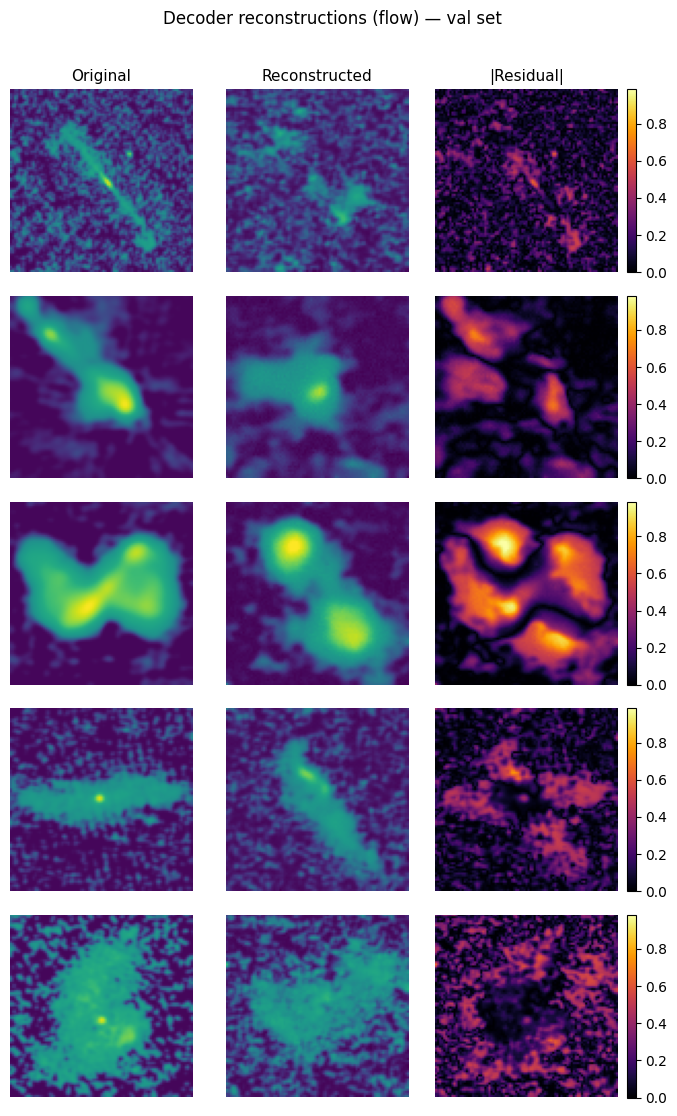

In [7]:
# 5 rows — one example per class (from val set)
# Columns: Original | Reconstructed | Residual

N_ROWS = 5

sample_indices = []
for c in range(min(N_ROWS, n_labels)):
    pos = np.where(val_y[:, c] > 0.5)[0]
    sample_indices.append(int(pos[0]) if len(pos) > 0 else c)

decoder.eval()
with torch.no_grad():
    z_sel = val_feats[sample_indices].to(device)
    if DECODER_TYPE == "flow":
        recon = decoder.sample(z_sel, n_steps=FLOW_N_STEPS)   # already clamped [0,1]
    else:
        recon = decoder(z_sel).cpu()
orig     = val_imgs[sample_indices]
residual = (orig - recon.cpu()).abs()

fig, axes = plt.subplots(N_ROWS, 3, figsize=(7, 2.2 * N_ROWS))
col_titles = ["Original", "Reconstructed", "|Residual|"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, pad=6)

for row in range(N_ROWS):
    active    = [label_names_subset[c] for c in range(n_labels) if val_y[sample_indices[row], c] > 0.5]
    row_label = ", ".join(active) if active else "none"
    images    = [orig[row, 0].numpy(), recon.cpu()[row, 0].numpy(), residual[row, 0].numpy()]
    for col, img in enumerate(images):
        ax   = axes[row, col]
        vmax = 1.0 if col < 2 else residual.max().item()
        cmap = "viridis" if col < 2 else "inferno"
        im   = ax.imshow(img, cmap=cmap, vmin=0, vmax=vmax)
        ax.axis("off")
        if col == 2:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    axes[row, 0].set_ylabel(row_label, fontsize=9, rotation=0, labelpad=90, va="center", ha="right")

plt.suptitle(f"Decoder reconstructions ({DECODER_TYPE}) — val set", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 7. Conditional NSF — Neural Spline Flow

The **Neural Spline Flow** (`zuko.flows.NSF`) models the conditional distribution
`p(z | y)` over BYOL projections, where `y` is a binary morphology label vector.

### Architecture

Each of the `n_flow_transforms` coupling layers applies a monotone
**rational-quadratic spline** to a subset of dimensions.  The spline parameters
(knot positions, widths, derivatives) are predicted by a small MLP conditioned
on `y`, making the transformation class-specific.  Composing these invertible
layers defines a flexible bijection  `f : ℝ^d → ℝ^d`.

### Training: negative log-likelihood

The change-of-variables formula gives an exact log-likelihood:

```
log p_θ(z | y) = log p_base( f(z; y) )  +  log |det J_f(z; y)|
```

- **First term**: rewards the transformed projection being near the Gaussian centre
- **Log-Jacobian**: prevents collapse — penalises volume-shrinking transformations

Training minimises:

```
Loss = −E_{z, y} [ log p_base(f(z; y))  +  log |det J_f(z; y)| ]
```

The NLL reaches large negative values (e.g. −368) because in ℝ^192 probability
*densities* can exceed 1, making log-densities positive.  More negative = better.

### Sampling

```python
y = torch.zeros(n, n_labels);  y[:, 0] = 1.0   # e.g. FRI class
z   = flow(y).sample()                          # project from N(0,I) via f⁻¹
img = decoder.sample(z, n_steps=20)             # decode to 89×89
```

In [8]:
# NSF is trained on the same space as the decoder (encoder features, FEAT_DIM)
# so that flow samples can be decoded directly.
flow = zuko.flows.NSF(
    features=FEAT_DIM,
    context=n_labels,
    transforms=CONFIG["n_flow_transforms"],
    randperm=True,
)
flow = flow.to(device)

n_params_flow = sum(p.numel() for p in flow.parameters() if p.requires_grad)
print(f"NSF parameters:    {n_params_flow:,}")
print(f"Feature dim:       {FEAT_DIM}")
print(f"Context dim:       {n_labels} ({label_names_subset})")
print(f"Coupling layers:   {CONFIG['n_flow_transforms']}")

# Quick sanity check
_y = torch.zeros(2, n_labels, device=device)
_y[0, 0] = 1.0
_z = torch.randn(2, FEAT_DIM, device=device)
_lp = flow(_y).log_prob(_z)
_s  = flow(_y).sample()
print(f"log_prob shape: {_lp.shape} | sample shape: {_s.shape}")
del _y, _z, _lp, _s

NSF parameters:    2,430,976
Feature dim:       192
Context dim:       5 (['FRI', 'FRII', 'Hybrids', 'Spirals', 'Relaxed doubles'])
Coupling layers:   8
log_prob shape: torch.Size([2]) | sample shape: torch.Size([2, 192])


## 8. Load or Train NSF

If `CONFIG["generative_dir"]` is set, the NSF is loaded from `nsf.pt`.
Otherwise it is trained by minimising `−log p(z | y)` over the training projections.

- **No images needed** — operates entirely in projection space
- **Regularisation**: small Gaussian noise on input projections (`flow_feat_noise`)
  acts as data augmentation, smoothing the learned distribution
- **Early stopping**: on validation NLL

In [9]:
torch.manual_seed(CONFIG["seed"])

if _gen_dir is not None:
    # ── Load pre-trained NSF ───────────────────────────────────────────────────
    _ckpt = torch.load(_gen_dir / "nsf.pt", map_location=device, weights_only=False)
    flow = zuko.flows.NSF(
        features=_ckpt["feat_dim"],
        context=_ckpt["n_labels"],
        transforms=_ckpt["n_transforms"],
        randperm=True,
    ).to(device)
    flow.load_state_dict(_ckpt["model_state_dict"])
    flow.eval()
    print(f"Loaded NSF from {_gen_dir.name}")
    print(f"  feat_dim={_ckpt['feat_dim']} | n_labels={_ckpt['n_labels']} | best_val_nll={_ckpt['best_val_nll']:.4f} | stopped at epoch {_ckpt['epoch']+1}")
else:
    # ── Train from scratch ─────────────────────────────────────────────────────
    FLOW_PATIENCE   = CONFIG.get("flow_patience", 20)
    FLOW_WD         = CONFIG.get("flow_weight_decay", 0.0)
    FLOW_FEAT_NOISE = CONFIG.get("flow_feat_noise", 0.0)
    print(f"NSF: WD={FLOW_WD} | feat_noise_std={FLOW_FEAT_NOISE}")

    train_f_t = train_feats
    val_f_t   = val_feats
    train_y_t = torch.from_numpy(train_y)
    val_y_t   = torch.from_numpy(val_y)

    bs = CONFIG["batch_size"]
    train_loader_flow = DataLoader(TensorDataset(train_f_t, train_y_t), batch_size=bs, shuffle=True, drop_last=True)
    val_loader_flow   = DataLoader(TensorDataset(val_f_t,   val_y_t),   batch_size=bs, shuffle=False)

    opt_flow   = torch.optim.Adam(flow.parameters(), lr=CONFIG["lr"], weight_decay=FLOW_WD)
    sched_flow = torch.optim.lr_scheduler.CosineAnnealingLR(opt_flow, T_max=CONFIG["flow_epochs"])

    flow_train_nll, flow_val_nll = [], []
    best_val_flow, best_state_flow, best_epoch_flow, patience_ctr = float("inf"), None, 0, 0

    for epoch in range(CONFIG["flow_epochs"]):
        flow.train()
        tr_nll = 0.0
        for z_b, y_b in train_loader_flow:
            z_b, y_b = z_b.to(device), y_b.to(device)
            if FLOW_FEAT_NOISE > 0.0:
                z_b = z_b + torch.randn_like(z_b) * FLOW_FEAT_NOISE
            loss = -flow(y_b).log_prob(z_b).mean()
            opt_flow.zero_grad(); loss.backward(); opt_flow.step()
            tr_nll += loss.item()
        tr_nll /= len(train_loader_flow)

        flow.eval()
        vl_nll = 0.0
        with torch.no_grad():
            for z_b, y_b in val_loader_flow:
                z_b, y_b = z_b.to(device), y_b.to(device)
                vl_nll += (-flow(y_b).log_prob(z_b).mean()).item()
        vl_nll /= len(val_loader_flow)

        flow_train_nll.append(tr_nll); flow_val_nll.append(vl_nll)
        sched_flow.step()

        if vl_nll < best_val_flow:
            best_val_flow, best_epoch_flow, patience_ctr = vl_nll, epoch, 0
            best_state_flow = copy.deepcopy(flow.state_dict())
        else:
            patience_ctr += 1
            if patience_ctr >= FLOW_PATIENCE:
                print(f"Early stopping at epoch {epoch+1} (patience={FLOW_PATIENCE})")
                break

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}/{CONFIG['flow_epochs']} "
                  f"| Train NLL: {tr_nll:.3f} | Val NLL: {vl_nll:.3f}"
                  f"{' *' if patience_ctr == 0 else ''}")

    flow.load_state_dict(best_state_flow)
    print(f"\nBest epoch: {best_epoch_flow+1} | Best val NLL: {best_val_flow:.3f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(flow_train_nll, label="Train NLL"); ax.plot(flow_val_nll, label="Val NLL")
    ax.axvline(x=best_epoch_flow, color="red", linestyle="--", linewidth=1.2,
               label=f"Best epoch {best_epoch_flow+1}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Negative Log-Likelihood")
    ax.set_title("NSF Training Loss (projection space)"); ax.legend()
    plt.tight_layout(); plt.show()
    print(f"Best val NLL: {best_val_flow:.3f}")

Loaded NSF from flow_initial_20260507_1437
  feat_dim=192 | n_labels=5 | best_val_nll=-367.9844 | stopped at epoch 185


## 9. Image Generation

Two usage modes for the trained decoder:

**Mode A — Reconstruct real images** (sanity check / quality assessment)
```
Real image → BYOL encoder → (projector) → z → decoder → reconstructed image
```

**Mode B — Generate from flow samples** (generative use)
```
Label y → NSF.sample() → z → decoder → generated image
```

Mode B is the end-to-end generative pipeline.  One row per class is shown,
with `n_gen_per_class` samples per row.

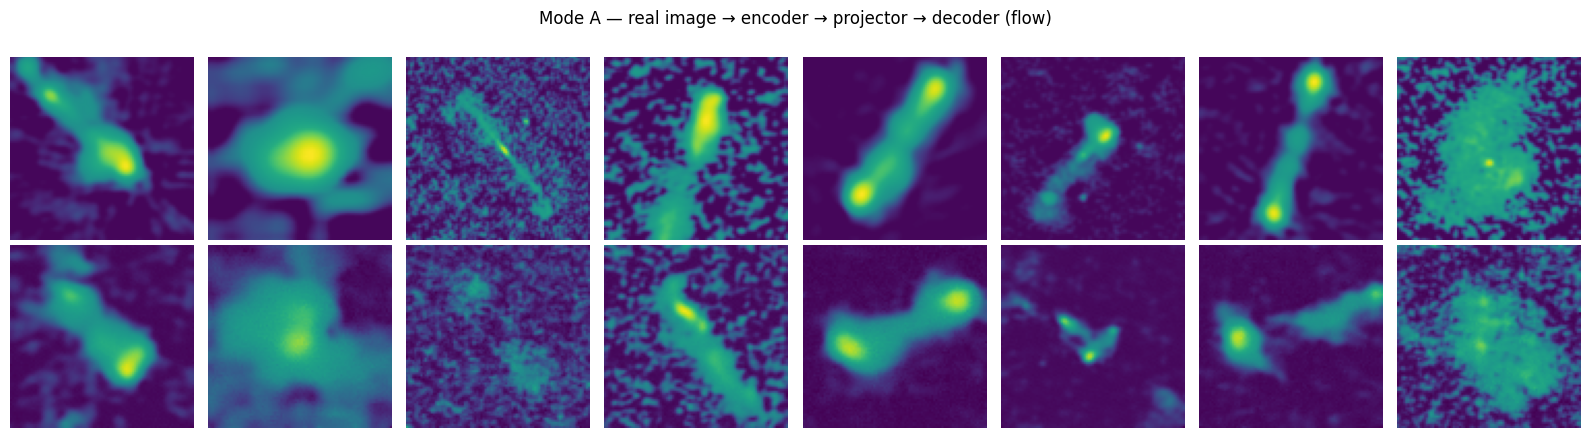

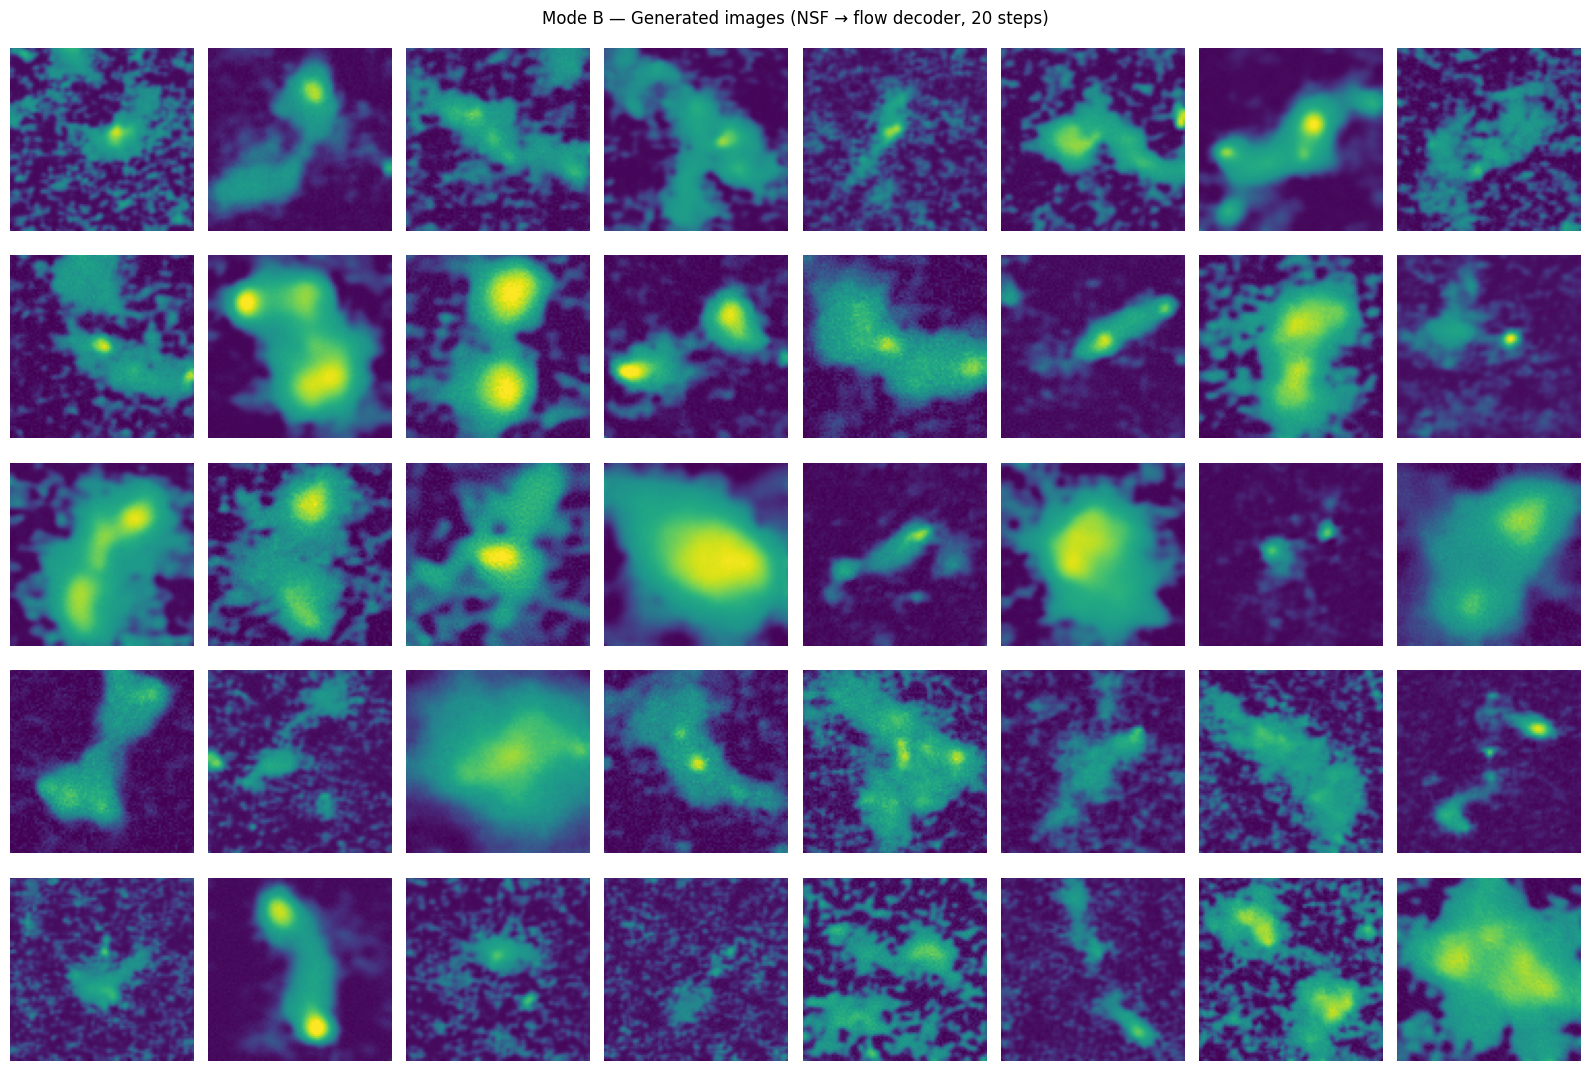

In [10]:
decoder.eval()
flow.eval()

DECODER_TYPE  = CONFIG.get("decoder_type", "flow")
FLOW_N_STEPS  = CONFIG.get("flow_n_steps", 20)
USE_PROJ      = CONFIG.get("use_projections", True)

def _decode(z):
    """Run decoder: z → image. Handles both decoder types."""
    if DECODER_TYPE == "flow":
        return decoder.sample(z, n_steps=FLOW_N_STEPS)   # returns (B,1,H,W) on z.device
    else:
        return decoder(z)   # returns (B,1,H,W) on z.device

# ─── Mode A: Reconstruct real images via encoder ──────────────────────────────
# Encode a real image → project (if use_projections) → decode → compare
n_recon = 8
sample_imgs = val_imgs[:n_recon].to(device)

with torch.no_grad():
    enc_out = byol.online_encoder(sample_imgs)
    if USE_PROJ:
        z_enc = byol.online_projector(enc_out)   # same space as decoder training
    else:
        z_enc = enc_out
    recon = _decode(z_enc).cpu()

fig, axes = plt.subplots(2, n_recon, figsize=(2 * n_recon, 4.5))
for i in range(n_recon):
    axes[0, i].imshow(sample_imgs[i, 0].cpu().numpy(), cmap="viridis", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].imshow(recon[i, 0].numpy(), cmap="viridis", vmin=0, vmax=1)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Decoded", fontsize=10)
plt.suptitle(f"Mode A — real image → encoder {'→ projector' if USE_PROJ else ''} → decoder ({DECODER_TYPE})")
plt.tight_layout()
plt.show()

# ─── Mode B: Generate from flow samples ──────────────────────────────────────
# Label y → NSF sample z → decode → image
def generate_images(label_vector, n_samples=8):
    flow.eval(); decoder.eval()
    y = torch.tensor(label_vector, dtype=torch.float32, device=device)
    y = y.unsqueeze(0).expand(n_samples, -1)
    with torch.no_grad():
        z = flow(y).sample()
        return _decode(z).cpu()

n_gen_per_class = 8
fig, axes = plt.subplots(n_labels, n_gen_per_class, figsize=(2 * n_gen_per_class, 2.2 * n_labels))
if n_labels == 1:
    axes = axes[None, :]

for row, name in enumerate(label_names_subset):
    label_vec = [0.0] * n_labels
    label_vec[row] = 1.0
    imgs_gen = generate_images(label_vec, n_samples=n_gen_per_class)
    for col in range(n_gen_per_class):
        axes[row, col].imshow(imgs_gen[col, 0].numpy(), cmap="viridis", vmin=0, vmax=1)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(name, fontsize=9, rotation=0, labelpad=55, va="center")

plt.suptitle(f"Mode B — Generated images (NSF → {DECODER_TYPE} decoder, {FLOW_N_STEPS} steps)", fontsize=12)
plt.tight_layout()
plt.show()

## 10. Projection Space Visualisations

### 10a. UMAP

Projects real training projections and NSF-generated projections into 2-D with UMAP.
Real projections are shown as circles; generated samples as stars (★).
A well-trained flow should place generated points inside the same clusters as real ones.

### 10b. Class interpolation

Linearly interpolates between two class-conditioned NSF samples in projection space
and decodes each step.  This reveals whether the decoder produces smooth, meaningful
transitions across classes.

Fitting UMAP on train projections…


/users/mbredber/.venv/lib64/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


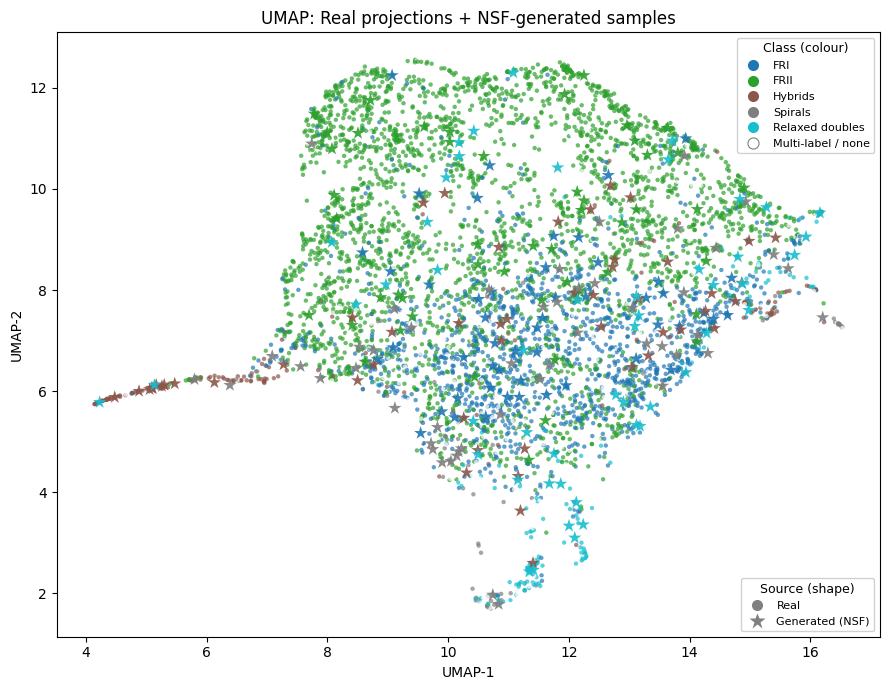

In [11]:
from matplotlib.lines import Line2D

feat_label = "projections" if USE_PROJECTIONS else "encoder features"
print(f"Fitting UMAP on train {feat_label}…")
reducer    = umap.UMAP(random_state=CONFIG["seed"], n_neighbors=15, min_dist=0.1)
umap_train = reducer.fit_transform(train_feats.numpy())   # (N_train, 2)

# Generate samples from the NSF for each class
n_gen_umap = max(50, 200 // n_labels)
flow.eval()
gen_zs, gen_class_ids = [], []
for row, name in enumerate(label_names_subset):
    label_vec = [0.0] * n_labels
    label_vec[row] = 1.0
    y = torch.tensor([label_vec], dtype=torch.float32, device=device).expand(n_gen_umap, -1)
    with torch.no_grad():
        z_gen = flow(y).sample().cpu().numpy()
    gen_zs.append(z_gen)
    gen_class_ids.extend([row] * n_gen_umap)

gen_zs_all    = np.concatenate(gen_zs, axis=0)
umap_gen      = reducer.transform(gen_zs_all)
gen_class_ids = np.array(gen_class_ids)

# ── Colour palette ────────────────────────────────────────────────────────────
cmap_cls     = plt.colormaps.get_cmap("tab10").resampled(n_labels)
class_colors = [cmap_cls(i) for i in range(n_labels)]

# ── Assign colours to real points ─────────────────────────────────────────────
real_colors = []
for i in range(len(train_y)):
    active = np.where(train_y[i] > 0.5)[0]
    real_colors.append(class_colors[active[0]] if len(active) == 1 else (1.0, 1.0, 1.0, 1.0))

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(umap_train[:, 0], umap_train[:, 1],
           c=real_colors, s=10, alpha=0.7, edgecolors="none", marker="o", zorder=2)
for i, name in enumerate(label_names_subset):
    mask = gen_class_ids == i
    ax.scatter(umap_gen[mask, 0], umap_gen[mask, 1],
               color=class_colors[i], marker="*", s=100, alpha=0.9, edgecolors="none", zorder=3)

class_handles = [
    Line2D([0], [0], marker="o", linestyle="none",
           markerfacecolor=class_colors[i], markeredgecolor="none",
           markersize=8, label=label_names_subset[i])
    for i in range(n_labels)
]
class_handles.append(
    Line2D([0], [0], marker="o", linestyle="none",
           markerfacecolor="white", markeredgecolor="gray", markeredgewidth=0.8,
           markersize=8, label="Multi-label / none")
)
leg1 = ax.legend(handles=class_handles, title="Class (colour)",
                 loc="upper right", fontsize=8, title_fontsize=9, framealpha=0.9)
ax.add_artist(leg1)
ax.legend(handles=[
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="gray",
           markeredgecolor="none", markersize=8, label="Real"),
    Line2D([0], [0], marker="*", linestyle="none", markerfacecolor="gray",
           markeredgecolor="none", markersize=12, label="Generated (NSF)"),
], title="Source (shape)", loc="lower right", fontsize=8, title_fontsize=9, framealpha=0.9)

ax.set_title(f"UMAP: Real {feat_label} + NSF-generated samples")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
plt.tight_layout(); plt.show()

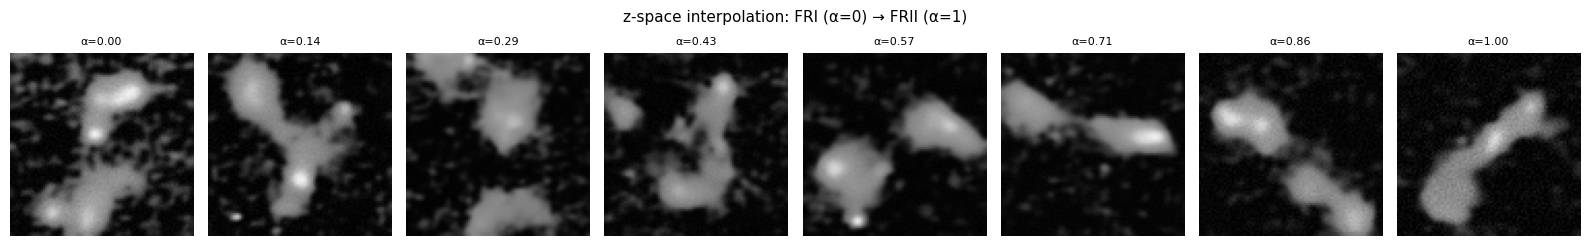

In [12]:
if n_labels >= 2:
    name_a, name_b = label_names_subset[0], label_names_subset[1]
    label_a = [0.0] * n_labels;  label_a[0] = 1.0
    label_b = [0.0] * n_labels;  label_b[1] = 1.0

    ya = torch.tensor([label_a], dtype=torch.float32, device=device)
    yb = torch.tensor([label_b], dtype=torch.float32, device=device)
    with torch.no_grad():
        za = flow(ya).sample()
        zb = flow(yb).sample()

    n_steps  = 8
    alphas   = torch.linspace(0.0, 1.0, n_steps, device=device)
    z_interp = torch.stack([(1 - a) * za + a * zb for a in alphas]).squeeze(1)

    decoder.eval()
    imgs_interp = _decode(z_interp).cpu()   # handles both "cnn" and "flow" decoders

    fig, axes = plt.subplots(1, n_steps, figsize=(2 * n_steps, 2.5))
    for i, ax in enumerate(axes):
        ax.imshow(imgs_interp[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"α={alphas[i]:.2f}", fontsize=8)
        ax.axis("off")
    plt.suptitle(f"z-space interpolation: {name_a} (α=0) → {name_b} (α=1)", fontsize=11)
    plt.tight_layout(); plt.show()
else:
    print("Need ≥ 2 labels for interpolation — skipping.")

## 11. Pixel Intensity Histogram Comparison

Compares the pixel intensity distribution of real, reconstructed, and generated images.
A good generative model should produce images whose intensity statistics match the real data.

**Settings** (edit at the top of the cell below):

| Setting | Options | Default |
|---------|---------|---------|
| `CLASS_SUBSET` | `"full"` \| class name \| list of names/ints | `"full"` |
| `PIXEL_MODE` | `"all"` \| `"brightest"` \| `"sum"` | `"all"` |

**`CLASS_SUBSET`** filters which images are included:
- `"full"` — all images
- A class name string, e.g. `"FRI"`, `"FRII"`, `"Hybrids"`
- A list, e.g. `["FRI", "FRII"]` — keeps images where *any* listed class is set

**`PIXEL_MODE`** controls what counts as one histogram sample:
- `"all"` — every pixel independently (n_images × 89 × 89 values)
- `"brightest"` — the single maximum pixel per image (n_images values)
- `"sum"` — the total pixel intensity sum per image (n_images values)

**RMAE** (Relative Mean Absolute Error) is shown in the legend for each generated set:
`RMAE = mean(|hist_real − hist_gen|) / mean(hist_real)`

Reconstructed/generated image arrays are cached in `notebooks/outputs/` after the
first run so this cell can be re-run independently.

In [13]:
# ── Pixel Intensity Histogram Comparison ─────────────────────────────────────
# Self-contained: reloads real images and labels from disk.
# Reconstructed/generated images are computed from the in-session model on
# first run, then cached to notebooks/outputs/ for independent re-runs.

# ── USER SETTINGS ─────────────────────────────────────────────────────────────
CLASS_SUBSET = "full"
# "full"                → all images, no class filtering
# a class name string   → e.g. "FRI", "FRII", "Hybrids" (see ALL_CLASS_NAMES below)
# a list of names/ints  → e.g. ["FRI", "FRII"]  or  [0, 1]

PIXEL_MODE = "all"
# "all"       → every pixel of every image is one sample  (n_images × H × W values)
# "brightest" → the single brightest pixel per image      (n_images values)
# "sum"       → the pixel-intensity sum per image         (n_images values)
# ─────────────────────────────────────────────────────────────────────────────

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

ROOT    = Path("..").resolve()
OUT_DIR = ROOT / "notebooks" / "outputs"
OUT_DIR.mkdir(exist_ok=True)

N_BINS = 30
EPS    = 1e-10

# Class name → column index mapping (matches notebook ALL_CLASS_NAMES)
_ALL_CLASS_NAMES = [
    "FRI", "FRII", "Hybrids", "Spirals", "Relaxed doubles",
    "C-curv", "S-curv", "Misalign", "Wings", "X-shaped",
    "Straight jets", "Multi hotspots", "Cont. jets", "Banding",
    "One-sided", "Restarted",
    "Cluster", "Merger", "Diffuse", "Unknown",
]

def _resolve_class_indices(subset):
    """Return a list of label column indices for the given CLASS_SUBSET."""
    if subset == "full":
        return None
    items = subset if isinstance(subset, list) else [subset]
    indices = []
    for item in items:
        if isinstance(item, int):
            indices.append(item)
        else:
            if item not in _ALL_CLASS_NAMES:
                raise ValueError(f"Unknown class name: {item!r}. "
                                 f"Choose from: {_ALL_CLASS_NAMES}")
            indices.append(_ALL_CLASS_NAMES.index(item))
    return indices

def _class_mask(labels_2d, col_indices):
    """Boolean mask: True where ANY of the given columns is 1."""
    return labels_2d[:, col_indices].any(axis=1)

def _extract_pixels(imgs, mode):
    """Flatten images according to PIXEL_MODE. Returns 1-D array."""
    flat = imgs.reshape(len(imgs), -1)
    if mode == "all":
        return flat.ravel()
    elif mode == "brightest":
        return flat.max(axis=1)
    elif mode == "sum":
        return flat.sum(axis=1)
    else:
        raise ValueError(f"Unknown PIXEL_MODE: {mode!r}. "
                         "Choose 'all', 'brightest', or 'sum'.")

# ── 1. Real images & labels ───────────────────────────────────────────────────
real_path  = ROOT / "data" / "processed" / "lotss" / "images_filtered.npy"
label_path = ROOT / "data" / "processed" / "lotss" / "labels_filtered.npy"

real_imgs_all  = np.load(real_path).astype(np.float32)
real_lbls_all  = np.load(label_path)                    # (N, 20) multi-hot
if real_imgs_all.max() > 1.5:
    real_imgs_all = real_imgs_all / 255.0

class_indices = _resolve_class_indices(CLASS_SUBSET)
if class_indices is not None:
    real_mask = _class_mask(real_lbls_all, class_indices)
    real_imgs = real_imgs_all[real_mask]
    class_label = (CLASS_SUBSET if isinstance(CLASS_SUBSET, str)
                   else "+".join(str(c) for c in CLASS_SUBSET))
    print(f"Class filter:  {class_label}  "
          f"({real_mask.sum()} / {len(real_imgs_all)} images kept)")
else:
    real_mask  = None
    real_imgs  = real_imgs_all
    class_label = "full"

print(f"Real:          {len(real_imgs):6d} images")

# ── 2. Reconstructed & generated images ──────────────────────────────────────
recon_cache  = OUT_DIR / "gen_reconstructed.npy"
gen_cache    = OUT_DIR / "gen_generated.npy"
gen_lbl_cache = OUT_DIR / "gen_labels.npy"   # conditioning labels for gen images

if recon_cache.exists() and gen_cache.exists():
    recon_imgs_all = np.load(recon_cache)
    gen_imgs_all   = np.load(gen_cache)
    gen_lbls_all   = (np.load(gen_lbl_cache) if gen_lbl_cache.exists() else None)
    print(f"Reconstructed: {len(recon_imgs_all):6d} images  (loaded from cache)")
    print(f"Generated:     {len(gen_imgs_all):6d} images  (loaded from cache)")
else:
    assert 'decoder' in dir() and 'byol' in dir() and 'flow' in dir(), (
        "Model variables not found. Run Cell 5 and Cell 7 first, "
        "or ensure cached .npy files exist in notebooks/outputs/."
    )

    _device       = next(decoder.parameters()).device
    _decoder_type = CONFIG.get("decoder_type", "flow")
    _flow_steps   = CONFIG.get("flow_n_steps", 20)
    _use_proj     = CONFIG.get("use_projections", True)
    _batch        = 128

    def _dec(z):
        if _decoder_type == "flow":
            return decoder.sample(z, n_steps=_flow_steps)
        return decoder(z)

    # Mode A: reconstruct from real images (uses full real_imgs_all, not filtered)
    n_compute = min(len(real_imgs_all), 1000)
    recon_list = []
    byol.eval(); decoder.eval()
    with torch.no_grad():
        for i in range(0, n_compute, _batch):
            x   = torch.from_numpy(real_imgs_all[i:i + _batch, None]).to(_device)
            enc = byol.online_encoder(x)
            z   = byol.online_projector(enc) if _use_proj else enc
            recon_list.append(_dec(z).cpu().numpy()[:, 0])
    recon_imgs_all = np.concatenate(recon_list)
    np.save(recon_cache, recon_imgs_all)
    print(f"Reconstructed: {len(recon_imgs_all):6d} images  (computed + cached)")

    # Mode B: generate from NSF conditioned on val labels
    flow.eval(); decoder.eval()
    gen_list, gen_lbl_list = [], []
    with torch.no_grad():
        for yi in val_labels_t[:n_compute]:
            z = flow(yi.unsqueeze(0).to(_device)).sample()
            gen_list.append(_dec(z).cpu().numpy()[0, 0])
            gen_lbl_list.append(yi.cpu().numpy())
    gen_imgs_all = np.stack(gen_list)
    gen_lbls_all = np.stack(gen_lbl_list)
    np.save(gen_cache,    gen_imgs_all)
    np.save(gen_lbl_cache, gen_lbls_all)
    print(f"Generated:     {len(gen_imgs_all):6d} images  (computed + cached)")

# Apply class filter to recon (recon[i] corresponds to real_imgs_all[i])
if class_indices is not None:
    recon_mask = real_mask[:len(recon_imgs_all)]
    recon_imgs = recon_imgs_all[recon_mask]
else:
    recon_imgs = recon_imgs_all

# Apply class filter to generated images (filter by conditioning label)
if class_indices is not None and gen_lbls_all is not None:
    gen_mask   = _class_mask(gen_lbls_all.astype(int), class_indices)
    gen_imgs   = gen_imgs_all[gen_mask]
    print(f"  → After class filter: recon={len(recon_imgs)}, gen={len(gen_imgs)}")
else:
    gen_imgs = gen_imgs_all

# ── 3. Extract pixel values according to PIXEL_MODE ──────────────────────────
n_use    = min(len(real_imgs), len(recon_imgs), len(gen_imgs))
px_real  = _extract_pixels(real_imgs[:n_use],  PIXEL_MODE)
px_recon = _extract_pixels(recon_imgs[:n_use], PIXEL_MODE)
px_gen   = _extract_pixels(gen_imgs[:n_use],   PIXEL_MODE)

mode_label = {"all": "pixels", "brightest": "images (brightest pixel)",
              "sum": "images (pixel sum)"}[PIXEL_MODE]
print(f"\nUsing {n_use:,} images each → {len(px_real):,} {mode_label} per set")

# ── 4. Bins — adapt range to pixel mode ──────────────────────────────────────
if PIXEL_MODE == "sum":
    # Sum can exceed [0,1]; use 99th percentile of real as upper bound
    hi   = float(np.percentile(px_real, 99)) * 1.05
    BINS = np.linspace(0, hi, N_BINS + 1)
else:
    BINS = np.linspace(0, 1, N_BINS + 1)

hist_real,  _ = np.histogram(px_real,  bins=BINS, density=True)
hist_recon, _ = np.histogram(px_recon, bins=BINS, density=True)
hist_gen,   _ = np.histogram(px_gen,   bins=BINS, density=True)

def rmae(h_ref, h_cmp):
    return np.mean(np.abs(h_ref - h_cmp)) / (np.mean(h_ref) + EPS)

rmae_recon = rmae(hist_real, hist_recon)
rmae_gen   = rmae(hist_real, hist_gen)

resid_recon = 2 * (hist_real - hist_recon) / (hist_real + hist_recon + EPS)
resid_gen   = 2 * (hist_real - hist_gen)   / (hist_real + hist_gen   + EPS)

# ── 5. Plot ───────────────────────────────────────────────────────────────────
x_labels = {
    "all":       "Intensity for each pixel",
    "brightest": "Brightest pixel intensity per image",
    "sum":       "Pixel intensity sum per image",
}

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(7, 5), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

ax_top.step(BINS[:-1], hist_real,  where="post", color="black",
            label=f"Real (n={len(px_real):,})")
ax_top.step(BINS[:-1], hist_recon, where="post", color="red",
            label=f"Reconstructed (n={len(px_recon):,}, RMAE={rmae_recon:.3f})")
ax_top.step(BINS[:-1], hist_gen,   where="post", color="orange",
            label=f"Generated (n={len(px_gen):,}, RMAE={rmae_gen:.3f})")

ax_top.set_yscale("log")
ax_top.set_ylabel("Normalised counts")
ax_top.legend(loc="upper right", fontsize=8)
ax_top.grid(True, color="lightgrey", linewidth=0.6)
title_parts = [f"class={class_label}", f"mode={PIXEL_MODE}"]
ax_top.set_title("Pixel intensity distribution  |  " + "  ·  ".join(title_parts),
                 fontsize=9)

ax_bot.step(BINS[:-1], resid_recon, where="post", color="red")
ax_bot.step(BINS[:-1], resid_gen,   where="post", color="orange")
ax_bot.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax_bot.set_ylim(-1, 1)
ax_bot.set_ylabel("2 × (Real − Gen)\n/ (Real + Gen)", fontsize=8)
ax_bot.set_xlabel(x_labels[PIXEL_MODE])
ax_bot.grid(True, color="lightgrey", linewidth=0.6)

plt.tight_layout()
suffix   = f"_{class_label}_{PIXEL_MODE}" if CLASS_SUBSET != "full" or PIXEL_MODE != "all" else ""
out_path = OUT_DIR / f"pixel_histogram_comparison{suffix}.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

Real:            7596 images
Reconstructed:   1024 images  (computed + cached)


NameError: name 'val_labels_t' is not defined